## Tarea 1 (2026) - Bastián Fierro Cabezas - 2021438823

## Respuestas

# Pregunta 1

- **Dataset inicial**. El dataset tiene 5.621 filas (observaciones) y 22 variables. De las variables disponibles, tenemos que 

    - student_id es entero (int64) y no posee valores faltantes.
    - age, study_hours, self_study_hours, online_classes_hours, social_media_hours, gaming_hours, sleep_hours, screen_time_hours, caffeine_intake_mg, upcoming_deadline, mental_health_score, drug_use, focus_index, burnout_level, productivity_score y exam_score son de tipo numérica (float64).
    - gender, academic_level, exercise_minutes, part_time_job e internet_quality son datos de tipo object (str). Notar que academic level tiene datos que tienen un espacio al final, exercise_minutes debería ser numérica, pero contiene registros con 'min', y part_time_job deberian ser 2 variables (yes/no) pero hay variantes con inicio en mayusculas y con minusculas.
    - El porcentaje de datos faltantes es alrededor del 11% por variables, sin embargo, drug_use tiene cerca de 73% por lo que no es posible extraer información util de esta variable.
 
Nota: Las estadisticas descriptivas del dataset original se encuentran en el bloque de desarrollo de código, también se incluye el número y porcentaje de datos faltantes por columna. En lo que sigue, supondremos que los datos faltantes se deben a MCAR, esto debido a que la cantidad de datos faltantes es consistente y aleatoria (ver gráfico de Missing)

- **Proceso de Limpieza**. Para poder llevar el dataset inicial a un dataset analítico y limpio se procedió de la siguiente forma:

    En resumen: 
    1. Se leyeron los datos desde el csv (student_productivity.csv).
    2. Se realizó un análisis exploratorio descriptivo (previsualización del dataset, tipos de datos, estadisticas descriptivas, cantidad de NaN y tamaño del dataset)
    3. Se limpiaron los datos, eliminando la columna "drugs_use" por tener más de 72% de datos faltantes, se eliminó el texto en "exercise_minutes" y además se transformó a hora por consistencia de unidades de medida. Se normalizó usando lower los datos de "part_time_job" y se mapeó a 0 (sin trabajo part time) y 1 (con trabajo part time). Se mapeó la variable categorica ordinal "academic_level" a numérico para ingresar al modelo, se reescaló "caffeine_intake_mg" a gramos para estabilidad numérica de los modelos, se generaron variables dummies para gender por ser variable nominal (usando gender Female como referencia), y se mapeó "internet_quality" a numérica para el modelo por ser ordinal.
    4. Se eliminaron los registros donde "exam_score" era faltante dado que es nuestra variable respuesta. Se generó la variable binaria "took_exam" como 1 si asiste al examen y 0 si no.
    5. Se hace un análisis de correlación para selección de variables. Aquellas con alta correlación, mayor a 0.5, (focus_index, mental_health_score) son eliminadas para prevenir multicolinealidad. Se eliminan registros faltantes. Además, variables como "self_study_hours" y "online_classes_hours" fueron eliminadas por tener correlación cercana a 0 con la variable objetivo, además contextualmente deberían ser explicadas por study_hours.
    6. Se hace un análisis de Factor de inflación de varianza (VIF) para quitar variables (burnout_level) que presenten problemas de alta colinealidad (VIF>5).

    Nota: Dada la cantidad de registros y la reducción del 28% del tamaño del dataset, se optó por no imputar datos para no obtener sesgo artificial y preservar realidad estadística.

- **Dataset limpio**. Luego de aplicar limpieza al dataset original, obtenemos

    - 4051 filas (observaciones) y 18 columnas (variables)
    - Las variables que tenemos disponibles finalmente son: student_id, age, academic_level, study_hours, social_media_hours, gaming_hours, sleep_hours, screen_time_hours, part_time_job, upcoming_deadline, internet_quality, productivity_score, exam_score, exercise_hours, caffeine_intake_g, gender_Male, gender_Other, took_exam.
    - Nuestra variable objetivo para las preguntas 2, 3, 4 y 5 es took_exam, mientras que para las preguntas 6, 7, 8 y 9 se usará exam_score (pero redondeado).

# Pregunta 2

Nos piden ajustar un modelo OLS (Mínimos Cuadrados Ordinarios), para ello, inicialmente definimos nuestra matriz de diseño X, con todas las variables mencionadas anteriormente excepto student_id, exam_score y took_exam. También añadimos el vector constante a nuestra matriz X. Por otro lado, dado que queremos enfocarnos en si un estudiante asiste o no a un examen, nuestra variable respuesta (y) es dada por took_exam. Posterior a ello, nos quedamos con aquellas variables significativas para incluir en el modelo OLS final. 

Las variables con las cuales nos quedamos finalmente son: gaming_hours, sleep_hours, screen_time_hours, part_time_job, upcoming_deadline, productivity_score.


| Coeficiente | Valor coeficiente | Error estándar | p-value |
|-------------|-------------------|----------------|---------|
|const              |    0.5904   |   0.032         |0.000   |    
|gaming_hours       |   -0.0091   |   0.004         |0.011   |  
|sleep_hours        |    0.0169   |   0.003         |0.000   |    
|screen_time_hours  |   -0.0057   |   0.002         |0.000   |   
|part_time_job      |   -0.0218   |   0.008         |0.004   |   
|upcoming_deadline  |   -0.0211   |   0.008         |0.006   |   
|productivity_score |    0.0075   |   0.000         |0.000   |

Interpretación de coeficientes significativos (nivel de significancia = 0.05):

- **gaming_hours** (-0.0091): Por cada hora adicional dedicada a videojuegos, la probabilidad de asistir al examen disminuye en 0.91 puntos porcentuales.

- **sleep_hours** (+0.0169): Por cada hora adicional de sueño, la probabilidad aumenta en 1.69 puntos porcentuales.

- **screen_time_hours**	(-0.0057): Por cada hora adicional de tiempo frente a pantallas, la probabilidad disminuye en 0.57 puntos porcentuales.

- **part_time_job** (-0.0218): Tener un trabajo part time (en comparación a no tenerlo) reduce la probabilidad de asistir en 2.18 puntos porcentuales.

- **upcoming_deadline** (-0.0211): Tener una fecha límite próxima (vs. no tenerla) reduce la probabilidad en 2.11 puntos porcentuales.

- **productivity_score** (+0.0075): Por cada punto adicional en el puntaje de productividad, la probabilidad aumenta en 0.75 puntos porcentuales.

Las siguientes variables no muestran una relación estadísticamente significativa con la asistencia al examen (sus coeficientes no son distinguibles de cero): age, academic_level, study_hours, social_media_hours, internet_quality, exercise_hours, caffeine_intake_g, gender_Male, gender_Other.

En base a lo anterior, podemos decir que tener una fecha límite de entrega y/o un trabajo part time pueden alejar a un alumno de presentarse a un examen. Del mismo modo habitos recreativos como horas de juego y tiempo en pantallas pueden también influir negativamente. Por otro lado, un buen descanso y percepción de productividad pueden empujar a tener mayor probabilidad de asistencia a un examen.

Según el $R^2$, el modelo es capaz de explicar el 23.6% de la varianza de los datos. El $R^2$ y $R^2_{\text{adj}}$ son practicamente iguales, lo que sugiere que no hay penalización por grados de libertad proveniente de los datos. Sin embargo, al ser un modelo ajustado por OLS, debemos tener en cuenta que los valores que puede tomar su salida puede estar fuera de [0,1]



# Pregunta 3

Para el modelo Probit, se comenzó utilizando las mismas variables explicativas (todas las disponibles del dataset limpio) que en el caso de OLS y también misma variable respuesta.

Dado que hicimos selección de variables por medio de p-value, nos quedamos con las siguientes variables para el modelo final:
study_hours, sleep_hours, screen_time_hours, part_time_job, upcoming_deadline, productivity_score, y caffeine_intake_g.

| Coeficiente | Valor Coeficiente | Cambio Marginal (dy/dx) | Error Estándar | p-value |
|-------------|-------------------|-------------------------|----------------|---------|
|const               | -1.4881 |    -    |  0.349 |          0.000  |    
|study_hours         | -0.1079 | -0.0076 |  0.033 |          0.001  |    
|sleep_hours         |  0.2112 |  0.0149 |  0.042 |          0.000  |     
|screen_time_hours   | -0.0882 | -0.0062 |  0.018 |          0.000  |   
|part_time_job       | -0.2970 | -0.0210 |  0.091 |          0.001  |    
|upcoming_deadline   | -0.2447 | -0.0173 |  0.088 |          0.005  |    
|productivity_score  |  0.1298 |  0.0092 |  0.007 |          0.000  |     
|caffeine_intake_g   | -0.6047 | -0.0427 |  0.306 |          0.048  |

Interpretación de cambios marginales (variables del modelo final):

- **study_hours** (-0.0076): Por cada hora adicional de estudio, la probabilidad disminuye en 0.76 puntos porcentuales. (Contraintuitivo, puede que estudiar más de la cuenta cause efectos contrarios).

- **sleep_hours** (+0.0149): Por cada hora adicional de sueño, la probabilidad aumenta en 1.49 puntos porcentuales.

- **screen_time_hours** (-0.0062): Por cada hora adicional frente a pantallas, la probabilidad disminuye en 0.62 puntos porcentuales.

- **part_time_job** (-0.0210): Tener un trabajo a tiempo parcial (vs. no tenerlo) reduce la probabilidad en 2.10 puntos porcentuales.

- **upcoming_deadline** (-0.0173): Tener una fecha límite próxima (vs. no tenerla) reduce la probabilidad en 1.73 puntos porcentuales.

- **productivity_score** (+0.0092): Por cada punto adicional en productividad, la probabilidad aumenta en 0.92 puntos porcentuales.

- **caffeine_intake_g** (-0.0427): Por cada gramo adicional de ingesta de cafeína, la probabilidad disminuye en 4.27 puntos porcentuales. 

Notar que para este modelo, *caffeine_intake_g* se encuentra casi al limite de p-value umbral (0.05)

Notar que no se puede interpretar los coeficientes del modelo Probit directamente, ya que a diferencia OLS, los coeficientes de Probit ellos están en escala z-score, solo se permiten interpretar su signo (si aumenta o disminuye su efecto). Por esa razón se utilizan los efectos marginales para poder interpretarse.

Por otro lado, la métrica Pseudo-$R^2$ (0.5666) significa que el modelo mejora la verosimilitud en aproximadamente 57% respecto al modelo nulo (sin predictores). Esto implica buen ajuste.



# Pregunta 4

Al igual que los 2 modelos anteriores, Para Logit se utilizaron inicialmente todas las covariables disponibles para luego quedarnos con aquellas que son significativas (a nivel de significancia 0.05).

Las variables explicativas a incluir en el modelo Logit final son:
study_hours, sleep_hours, screen_time_hours, part_time_job, upcoming_deadline y productivity_score.

| Coeficiente | Valor Coeficiente | Cambio Marginal (dy/dx) | Error Estándar | p-value |
|-------------|-------------------|-------------------------|----------------|---------|
|const              | -3.2536 |    -    |  0.612  |   0.000  | 
|study_hours        | -0.2053 | -0.0079 |  0.063  |   0.001  |    
|sleep_hours        |  0.4083 |  0.0157 |  0.078  |   0.000  |    
|screen_time_hours  | -0.1547 | -0.0060 |  0.033  |   0.000  |    
|part_time_job      | -0.5400 | -0.0208 |  0.168  |   0.001  |    
|upcoming_deadline  | -0.3659 | -0.0141 |  0.164  |   0.026  |    
|productivity_score |  0.2382 | 0.0092  |  0.012  |   0.000  |

De forma similar a Probit, la innterpretación de cambios marginales significativos (nivel de significancia 0.05) son dados por:

- **study_hours** (-0.0079): Por cada hora adicional de estudio, la probabilidad disminuye en 0.79 puntos porcentuales. (Contraintuitivo, puede que estudiar más de la cuenta cause efectos contrarios).

- **sleep_hours** (+0.0157): Por cada hora adicional de sueño, la probabilidad aumenta en 1.57 puntos porcentuales.

- **screen_time_hours** (-0.0060): Por cada hora adicional frente a pantallas, la probabilidad disminuye en 0.60 puntos porcentuales.

- **part_time_job** (-0.0208): Tener un trabajo a tiempo parcial (vs. no tenerlo) reduce la probabilidad en 2.08 puntos porcentuales.

- **upcoming_deadline** (-0.0141): Tener una fecha límite próxima (vs. no tenerla) reduce la probabilidad en 1.41 puntos porcentuales.

- **productivity_score** (+0.0092): Por cada punto adicional en productividad, la probabilidad aumenta en 0.92 puntos porcentuales.

Notar que a diferencia de Probit, la variable *caffeine_intake_g* no fue significativa, superando el umbral de p-value 0.05. Por lo demás comparten las mismas variables explicativas.

Notar también que para modelos Logit, los coeficientes que el modelo entrega son Log-odds, por lo que para interpretar los cambios, se usaron los efectos marginales del modelo.

La métrica Pseudo-$R^2$ (0.5644) significa que el modelo mejora la verosimilitud en aproximadamente 57% respecto al modelo nulo (sin predictores). Esto implica buen ajuste.

# Pregunta 5

- Diferencias entre modelos:
Los coeficientes no son comparables directamente entre OLS y los modelos no lineales (Probit y Logit) porque están en escalas distintas: el OLS entrega efectos en unidades de probabilidad (puntos porcentuales), el Probit en índice z (escala de la normal estándar) y el Logit en log-odds. Para estos últimos se utiliza el cambio marginal dy/dx. Notemos que OLS nos da una aproximación lineal que no necesariamente esté entre 0 y 1 (pueden haber valores por encima o debajo de estos limites), mientras que Probit y Logit modelan entre 0 y 1. OLS posee una métrica de varianza explicada $R^2$ pero no es comparable a los Pseudo-$R^2$ de Probit y Logit.

- Tanto los modelos Probit como Logit son adecuados para responder a las preguntas de investigación, ya que, como modelamos una clasificación binaria, estos modelos no lineales nos asegura tener valores entre 0 y 1. Ambos están libres de supuestos fuertes como los de OLS y capturan de mejor forma relaciones no lineales. Probit y Logit poseen coeficientes muy efectos marginales casi iguales, sin embargo, comparando los Pseudo-$R^2$ (0.566 Probit, 0.5644 Logit) y Log-Verosimilitud (-517.4 Probit, -520.02 Logit) entre ambos modelos, Probit tiene un leve mejor desempeño e incluye una variable que aporta a la explicabilidad del fenómeno, por lo que sería algo más apropiado para responder preguntas de investigación.

- Variables robustas a especificación:
part_time_job, productivity_score, screen_time_hours, sleep_hours, upcoming_deadline.
Principalmente porque están presentes en los 3 modelos, su p-value indican que son altamente significativas y tienen consistencia de signo en los 3 modelos. Comoo mencionamos antes, los modelos no lineales (Probit y Logit) comparten sus covariables, excepto *caffeine_intake_g* la cual solo está presente en Probit.

Observación: Dentro de *Códigos Problema 5* se encuentra una tabla tipo Stargazer con los 3 modelos a comparar.

# Pregunta 6

Ajustamos un modelo Poisson para modelar la nota de examen de los estudiantes (dado que es una variable de conteo), para ello discretizamos la variable exam_score mediante redondeo para obtener exam_score_int, la cual será nuestra variable respuesta (y). Nuestras covariables son las mismas que en los modelos anteriores, solo que nos concentramos en aquellos alumnos cuya variable took_exam es igual a 1.

Notar que los coeficientes deben interpretarse mediante como cambio porcentual calculandose como $100\%\cdot(\exp(\beta)-1)$. 

| Coeficiente | Valor | Efecto en % ($100\%\cdot(\exp(\beta)-1)$) | Error Estándar | p-value |
|-------------|-------------------|-------------------------|----------------|---------|
|const              |  1.7214 |     -   | 0.031 | 0.000 | 
|study_hours        | -0.0167 | -1.6560 | 0.003 | 0.000 |    
|social_media_hours | -0.0195 | -1.9326 | 0.002 | 0.000 |    
|gaming_hours       | -0.0135 | -1.3380 | 0.003 | 0.000 |    
|sleep_hours        |  0.0488 |  5.0062 | 0.003 | 0.000 |    
|screen_time_hours  | -0.0129 | -1.2809 | 0.001 | 0.000 |    
|part_time_job      | -0.0573 | -5.5697 | 0.007 | 0.000 |    
|upcoming_deadline  | -0.1169 | -11.0367| 0.007 | 0.000 |    
|productivity_score |  0.0296 |  3.0064 | 0.000 | 0.000 |    
|exercise_hours     |  0.0161 |  1.6210 | 0.005 | 0.001 | 
|caffeine_intake_g  | -0.1027 | -9.7625 | 0.025 | 0.000 |

Interpretación de los coeficientes significativos:

- **study_hours:** Por cada hora adicional de estudio, el puntaje esperado en el examen disminuye en un 1.65%.
(Al igual que en modelos anteriores, esto puede parecer contraintuitivo; podría reflejar que quienes estudian más ya tienen menor rendimiento base o que la variable capta otro fenómeno, como estudio de última hora ineficaz).

- **social_media_hours:** Por cada hora adicional en redes sociales, el puntaje esperado disminuye en un 1.93%.

- **gaming_hours:** Por cada hora adicional de videojuegos, el puntaje esperado disminuye en un 1.34%.

- **sleep_hours:** Por cada hora adicional de sueño, el puntaje esperado aumenta en un 5%. (efecto relevante)

- **screen_time_hours:** Por cada hora adicional frente a pantallas (en general), el puntaje esperado disminuye en un 1.28%.

- **part_time_job:** Tener un trabajo part time (en comparación con no tenerlo) reduce el puntaje esperado en un 5.57%. (efecto relevante)

- **upcoming_deadline:** Tener una fecha límite próxima (vs. no tenerla) reduce el puntaje esperado en un 11.04% (efecto grande).

- **productivity_score:** Por cada punto adicional en el puntaje de productividad, el puntaje esperado aumenta en un 3%.

- **exercise_hours:** Por cada hora adicional de ejercicio, el puntaje esperado aumenta en un 1.62%.

- **caffeine_intake_g**: Por cada gramo adicional de consumo de cafeína, el puntaje esperado disminuye en un 9.76% (Efecto relevante).

De aquí podríamos concluir que el tener una entrega próxima, con tener un trabajo a tiempo parcial y una ingesta de cafeina podrían tender a empeorar el rendimiento en el examen, mientras que la autopercepción de productividad alta, horas de ejercicios y de sueño adicionales pueden contribuir a una mejor calificación en el examen.


# Pregunta 7

Para poder ver si el modelo Poisson es adecuado, debemos asegurarnos de que no haya sobredispersión de los datos. Para ello, haremos un test de ratio $\chi^2/gl(res)$. 

En nuestro caso, dado que el ratio de $\chi^2/gl(res)$ 1.745 es mayor a 1, podemos sospechar de sobredispersión, la cual es confirmada por la significancia (p-value $\approx$ 0) del coeficiente en la regresión auxiliar. Por lo tanto, existe sobredispersión en los datos, implica que la varianza es mayor a la esperanza, incumpliendo el supuesto de la distribución de Poisson del modelo. Se sugiere utilizar un modelo Binomial Negativa para solventar este problema.

Adicionalmente, determinamos un valor óptimo de $\alpha$ usando como regresores la siguiente variable auxiliar:

$$\text{aux}=[(y-\lambda)^2-\lambda]/\lambda$$
$$ \lambda = \alpha \text{aux} $$

donde $\lambda$ corresponde a los valores predichos por el modelo Poisson e $y$ corresponde a la variable objetivo (resultado real)

En nuestro caso, el valor óptimo de alfa fue: $\alpha_{opt} = 0.0241$

# Pregunta 8

Para el modelo Binomial Negativo, inicialmente se utilizaron todas las variables disponibles del dataset, quedandonos luego con aquellas variables explicativas que resultaron significativas (resultan ser las mismas variables que utilizamos finalmente en el modelo de Poisson). Se utilizó el $\alpha$ optimo hallado. 

| Coeficiente | Valor | Efecto en % ($100\%\cdot(e^{\beta}-1)$) | Error Estándar | p-value |
|-------------|-------------------|-------------------------|----------------|---------|
|const               |   1.6565  |     -     |  0.039  |  0.000  | 
|study_hours         |  -0.0159  |  -1.5814  |  0.003  |  0.000  | 
|social_media_hours  |  -0.0213  |  -2.1035  |  0.003  |  0.000  | 
|gaming_hours        |  -0.0150  |  -1.4893  |  0.004  |  0.000  | 
|sleep_hours         |   0.0530  |   5.4390  |  0.004  |  0.000  | 
|screen_time_hours   |  -0.0141  |  -1.3958  |  0.002  |  0.000  | 
|part_time_job       |  -0.0615  |  -5.9652  |  0.009  |  0.000  | 
|upcoming_deadline   |  -0.1264  | -11.8706  |  0.009  |  0.000  | 
|productivity_score  |   0.0309  |   3.1383  |  0.000  |  0.000  | 
|exercise_hours      |   0.0169  |   1.7079  |  0.006  |  0.008  | 
|caffeine_intake_g   |  -0.1160  | -10.9495  |  0.032  |  0.000  |

Por defectom tiene el mismo linkage que en Poisson, por lo tanto, la interpretación de los coeficientes resulta de la misma manera, como cambio porcentual:

- **study_hours:** Por cada hora adicional de estudio, el puntaje esperado en el examen disminuye en un 1.58%.
(Al igual que en modelos anteriores, esto puede parecer contraintuitivo).

- **social_media_hours:** Por cada hora adicional en redes sociales, el puntaje esperado disminuye en un 2.10%.

- **gaming_hours:** Por cada hora adicional de videojuegos, el puntaje esperado disminuye en un 1.48%.

- **sleep_hours:** Por cada hora adicional de sueño, el puntaje esperado aumenta en un 5.44%.

- **screen_time_hours:** Por cada hora adicional frente a pantallas (en general), el puntaje esperado disminuye en un 1.4%.

- **part_time_job:** Tener un trabajo part time (en comparación con no tenerlo) reduce el puntaje esperado en un 5.98%.

- **upcoming_deadline:** Tener una fecha límite próxima (vs. no tenerla) reduce el puntaje esperado en un 11.87% (efecto grande).

- **productivity_score:** Por cada punto adicional en el puntaje de productividad, el puntaje esperado aumenta en un 3.14%.

- **exercise_hours:** Por cada hora adicional de ejercicio, el puntaje esperado aumenta en un 1.71%.

- **caffeine_intake_g**: Por cada gramo adicional de consumo de cafeína, el puntaje esperado disminuye en un 10.95%. (efecto grande).

A partir de lo anterior, se pueden obtener mismas interpretaciones que en las obtenidas anteriormente en el modelo Poisson.

# Pregunta 9

- Diferencias: Si bien no hay mucha diferencia entre los coeficientes de ambos modelos, descubrimos que en los datos existe sobredispersión, por lo cual se viola el supuesto de distribución de Poisson (E(X|Y) = Var(X|Y)) y se sugiere utilizar el modelo Binomial Negativo (que además tiene mejor Loglikelihood) para responder la pregunta de investigación. La magnitud de los efectos (porcentajes) se extrae de sus coeficientes, como $100\%\cdot(\exp(\beta)-1)$. 

- Variables robustas: Las variables robustas indican que, incluso corrigiendo por sobredispersión, los factores que realmente influyen en la puntuación del examen son: horas de sueño (positivo), productividad (positivo), ejercicio (positivo), y varios hábitos negativos como redes sociales, videojuegos, tiempo de pantalla, trabajo parcial, fecha límite próxima y consumo de gramos de cafeína (todos con efecto negativo).


Observación, en base a los modelos también de halló que las horas de estudio tienen una contribución negativa en el desempeño del estudiante, parece contraintuitivo y podría deberse a factores contextuales o externos que acompañan a esta variable.

Observación: Dentro de *Códigos Problema 9* se encuentra una tabla tipo Stargazer con los 2 modelos de conteo a comparar.

---

## Desarrollo del código

# Códigos Pregunta 1

**Enunciado:** Cargar la base de datos en el ambiente. Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario. Genere una variable binaria para indicar quienes dieron el test. Justifique su proceso.

- Importación de librerias

In [ ]:
# Importación de librerias a usar
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import missingno as msno
import seaborn as sns
from statsmodels.iolib.summary2 import summary_col
from statsmodels.stats.outliers_influence import variance_inflation_factor #VIF para multicolinealidad
from stargazer.stargazer import Stargazer, LineLocation
from IPython.core.display import HTML


import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

- Funciones utiles

In [62]:
def corr_plot(df):
    # Eliminamos la columna "student_id" ya que no es relevante para el análisis de correlación
    try:
        data = df.drop(columns="student_id")
    except:
        data = df.copy()

    corr = data.corr() # Calculamos la matriz de correlación

    # Gráfico de matriz de correlación
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title('Matriz de Correlación')
    plt.show()
    
    return corr

def max_correlacion(matriz_corr, n=5):
    # Conservamos solo el triángulo superior de la matriz (sin la diagonal) 
    # Esto evita pares duplicados como (A,B) y (B,A) y elimina los 1.0 de la diagonal
    triangulo_superior = np.triu(np.ones(matriz_corr.shape), k=1).astype(bool)
    matriz_limpia = matriz_corr.where(triangulo_superior)
    
    # 2. Convertir la matriz de formato ancho a formato largo (Pares de variables)
    pares_corr = matriz_limpia.stack().reset_index()
    pares_corr.columns = ['Variable_1', 'Variable_2', 'Correlacion']
    
    # 3. Ordenar todos los pares de correlación de mayor a menor
    pares_ordenados = pares_corr.sort_values(by='Correlacion', ascending=False)
    
    # 4. Extraer los 'n' más altos
    mas_altos = pares_ordenados.head(n)
    
    return mas_altos

- Carga y exploración inicial de datos

In [63]:
# Cargamos la data
df =  pd.read_csv("../../data/student_productivity.csv")

# Flag para controlar la impresión de outputs intermedios, para evitar saturar el notebook con prints
print_output = False
og_shape = df.shape

# Revisamos las primeras filas de la data
display(df.head())

# Revisamos la forma de la data
print("Número de filas y columnas (data sin procesar):", og_shape)

# Revisamos la información de la data
print("\nInformación general de la data:")
print(df.info()) #Información general de la data

# Revisamos las estadísticas descriptivas de la data
print("\nEstadisticas descriptivas de la data: \n")
display(df.describe(include="all"))

# Revisamos el número de valores nulos/NaN por columna
print("\nNúmero de valores nulos/NaN por columna:")
display(df.isna().sum()) # NaNs por columna
print("\nProporción de valores nulos/NaN en la data:")
display(df.isna().sum() / (df.shape[0])) # Proporción de NaNs en la data

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
0,1,20.0,NaN,Undergraduate,5.37,2.09,1.85,3.66,2.32,7.73,...,475.0,No,0.0,Good,3.0,NaN,19.01,31.77,42.59,25.08
1,2,16.0,Female,High School,5.85,5.04,1.87,3.60,2.79,6.11,...,362.0,no,0.0,Good,10.0,NaN,42.10,45.89,67.15,37.83
2,3,18.0,Female,Undergraduate,5.69,2.27,0.00,2.93,3.94,7.11,...,200.0,No,0.0,Average,5.0,NaN,21.93,37.07,37.68,18.66
3,4,24.0,Male,Undergraduate,2.32,1.06,2.30,4.34,2.37,8.54,...,233.0,No,1.0,Poor,3.0,1.0,13.47,43.63,12.83,1.00
4,5,24.0,Female,Postgraduate,3.87,2.63,2.54,3.71,1.30,7.69,...,159.0,No,1.0,Poor,2.0,NaN,19.95,56.62,18.53,7.78


Número de filas y columnas (data sin procesar): (5621, 22)

Información general de la data:
<class 'pandas.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   age                   4973 non-null   float64
 2   gender                5063 non-null   str    
 3   academic_level        4991 non-null   str    
 4   study_hours           5047 non-null   float64
 5   self_study_hours      4954 non-null   float64
 6   online_classes_hours  4939 non-null   float64
 7   social_media_hours    4965 non-null   float64
 8   gaming_hours          4965 non-null   float64
 9   sleep_hours           5068 non-null   float64
 10  screen_time_hours     5035 non-null   float64
 11  exercise_minutes      5022 non-null   str    
 12  caffeine_intake_mg    5021 non-null   float64
 13  part_time_job         4918 non-null   str 

,student_id,age,gender,academic_level,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,...,caffeine_intake_mg,part_time_job,upcoming_deadline,internet_quality,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
count,5621.000000,4973.000000,5063,4991,5047.000000,4954.000000,4939.000000,4965.000000,4965.000000,5068.000000,...,5021.000000,4918,4904.000000,5098,4946.000000,1518.000000,4988.000000,4905.000000,4983.000000,4912.000000
unique,NaN,NaN,3,6,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,4,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Male,Postgraduate,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,No,NaN,Good,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,2213,1395,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1838,NaN,1746,NaN,NaN,NaN,NaN,NaN,NaN
mean,2811.000000,20.510557,NaN,NaN,4.538708,2.480454,2.012296,3.002872,1.571458,7.023301,...,250.804820,NaN,0.501223,NaN,5.516983,0.661397,29.388119,45.633156,37.313526,18.840542
std,1622.787263,2.876399,NaN,NaN,1.819412,1.178094,0.983104,1.472740,1.112557,1.159948,...,143.685652,NaN,0.500049,NaN,2.873859,0.473391,9.996024,14.257283,16.841997,12.119456
min,1.000000,16.000000,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,...,0.000000,NaN,0.000000,NaN,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,1406.000000,18.000000,NaN,NaN,3.260000,1.660000,1.320000,2.000000,0.680000,6.250000,...,129.000000,NaN,0.000000,NaN,3.000000,0.000000,22.460000,35.770000,25.330000,9.410000
50%,2811.000000,20.000000,NaN,NaN,4.530000,2.480000,2.010000,2.990000,1.500000,7.015000,...,251.000000,NaN,1.000000,NaN,5.000000,1.000000,29.380000,45.650000,36.920000,17.990000
75%,4216.000000,23.000000,NaN,NaN,5.760000,3.280000,2.690000,4.030000,2.350000,7.820000,...,375.000000,NaN,1.000000,NaN,8.000000,1.000000,36.232500,55.410000,49.200000,27.410000



Número de valores nulos/NaN por columna:


student_id                 0
age                      648
gender                   558
academic_level           630
study_hours              574
self_study_hours         667
online_classes_hours     682
social_media_hours       656
gaming_hours             656
sleep_hours              553
screen_time_hours        586
exercise_minutes         599
caffeine_intake_mg       600
part_time_job            703
upcoming_deadline        717
internet_quality         523
mental_health_score      675
drug_use                4103
focus_index              633
burnout_level            716
productivity_score       638
exam_score               709
dtype: int64


Proporción de valores nulos/NaN en la data:


student_id              0.000000
age                     0.115282
gender                  0.099271
academic_level          0.112080
study_hours             0.102117
self_study_hours        0.118662
online_classes_hours    0.121331
social_media_hours      0.116705
gaming_hours            0.116705
sleep_hours             0.098381
screen_time_hours       0.104252
exercise_minutes        0.106565
caffeine_intake_mg      0.106743
part_time_job           0.125067
upcoming_deadline       0.127557
internet_quality        0.093044
mental_health_score     0.120085
drug_use                0.729941
focus_index             0.112613
burnout_level           0.127379
productivity_score      0.113503
exam_score              0.126134
dtype: float64

- Visualización de datos faltantes

<Axes: >

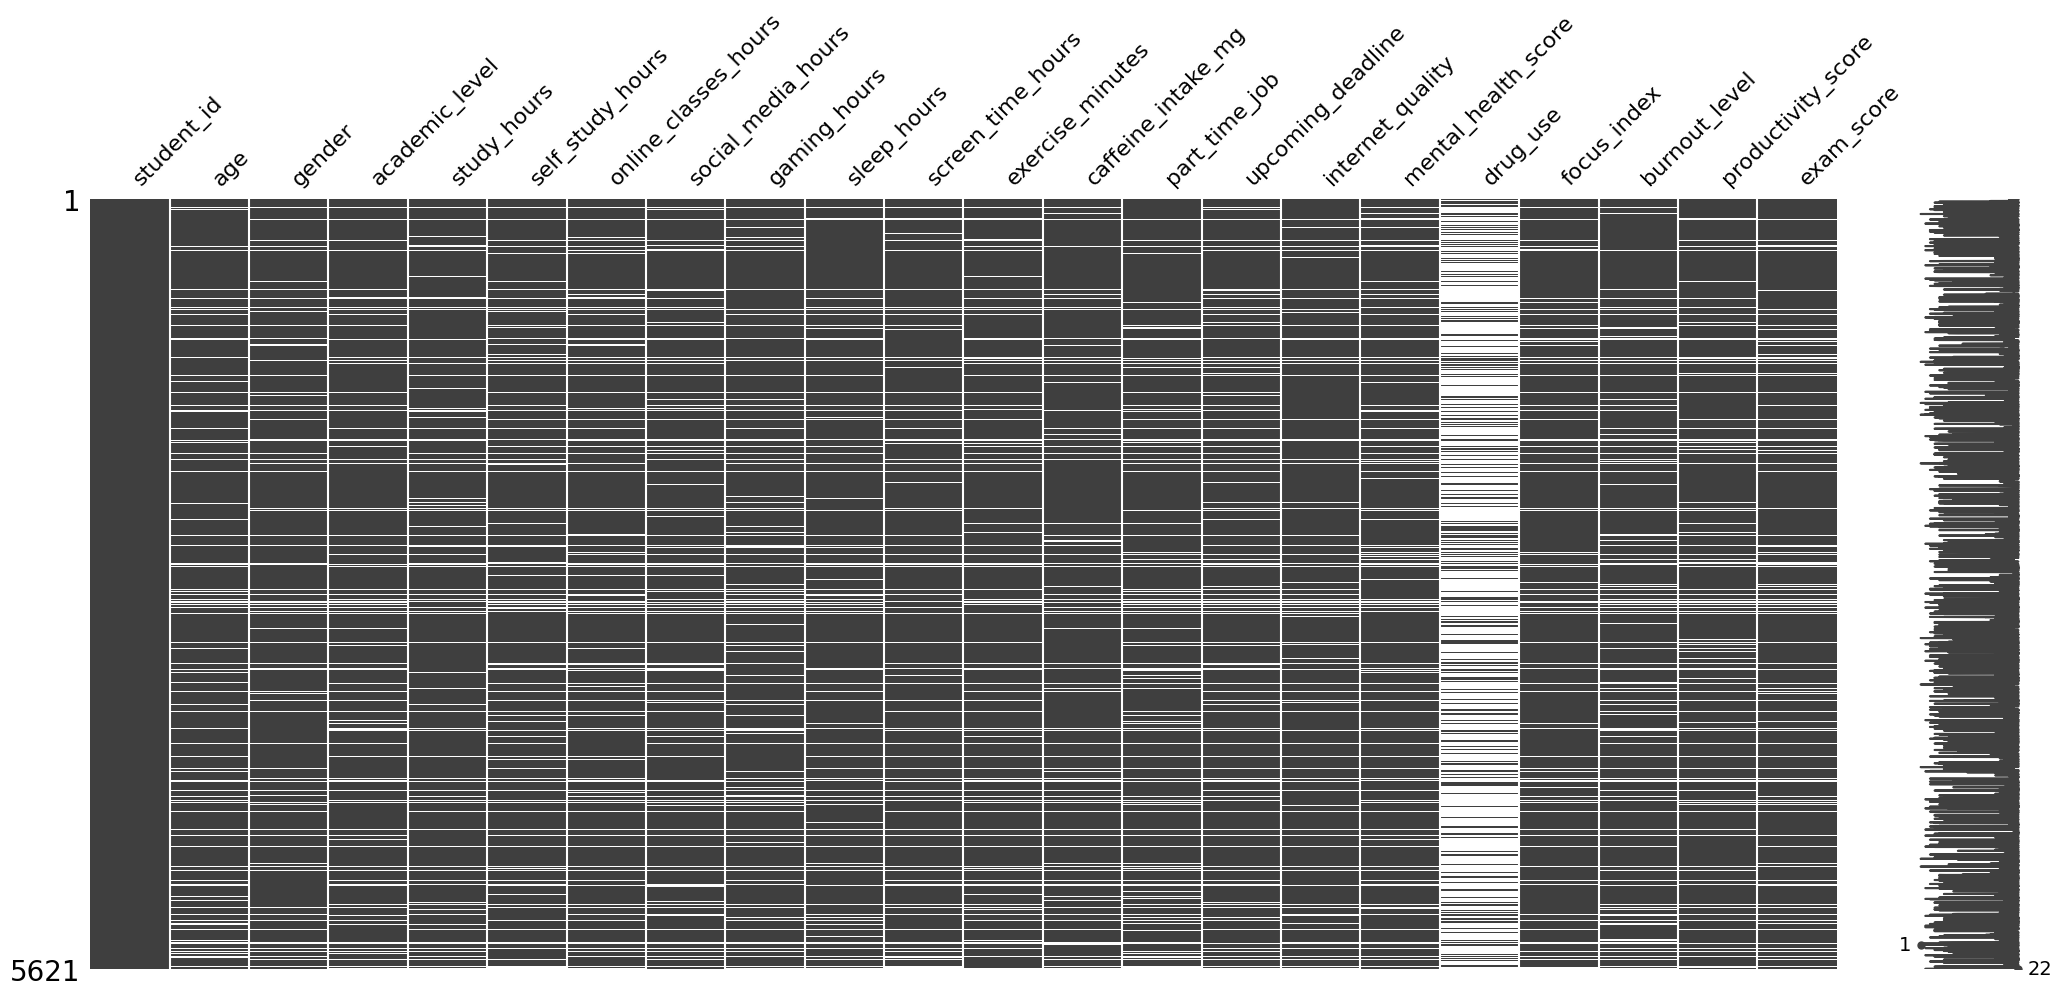

In [64]:
msno.matrix(df, )

- Limpieza de datos \
Con ayuda de DataWrangler, podemos ver hacer una breve exploración complementaria, la cual nos revela que hay columnas que tienen problemas de datos.

In [65]:
# Notamos que la columna "drug_use" tiene un 73% de datos faltantes, lo que es bastante alto, por lo que la eliminaremos del análisis.
df = df.drop(columns=["drug_use"])

# Exercise_minutes tiene datos numéricos pero están codificados como string, por lo que los convertiremos a numérico.
if print_output: print(df["exercise_minutes"].unique()) # Revisamos los valores únicos de la columna "exercise_minutes"
df["exercise_minutes"] = df["exercise_minutes"].str.strip().str.replace("min","") # Eliminamos espacios en blanco
df["exercise_minutes"] = df["exercise_minutes"].astype(float) # Convertimos a numérico, los errores se convierten en NaN 
df["exercise_hours"] = df["exercise_minutes"] / 60 # Creamos una nueva columna con las horas de ejercicio
if print_output: print(df["exercise_minutes"].unique()) # Revisamos los valores únicos de la columna "exercise_minutes" después de la conversión
df.drop(columns=["exercise_minutes"], inplace=True) # Eliminamos la columna original de minutos

# Según DataWragler, la columna "part_time_job" tiene datos "Yes" y "No", pero no están unificados
if print_output: print(df["part_time_job"].unique()) # Revisamos los valores únicos de la columna "part_time_job"
df["part_time_job"] = df["part_time_job"].str.strip().str.lower() # Unificamos los valores a minúsculas y sin espacios
if print_output: print(df["part_time_job"].unique()) # Revisamos los valores únicos de la columna "part_time_job"
df["part_time_job"] = df["part_time_job"].map({"yes": 1, "no": 0}) # Dejamos como variable binaria, donde 1 es "Yes" y 0 es "No"
if print_output: print(df["part_time_job"].unique()) # Revisamos los valores únicos de la columna "part_time_job"

# La columna "academic_level" tiene datos categóricos con espacios en blanco, por lo que los eliminaremos
if print_output: print(df["academic_level"].unique()) # Revisamos los valores únicos de la columna "academic_level"
df["academic_level"] = df["academic_level"].str.strip() # Eliminamos espacios en blanco
if print_output: print(df["academic_level"].unique()) # Revisamos los valores únicos de la columna "academic_level"

# Reescalamos la columna de "caffeine_intake_mg", dividiendo por 1000 para convertir de mg a g
# Esto es útil para evitar inestabilidad numérica y facilitar la interpretación de coef asociado
df["caffeine_intake_g"] = df["caffeine_intake_mg"] / 1000
df.drop(columns=["caffeine_intake_mg"], inplace=True) # Eliminamos la columna original de mg

# Generación de variables dummies para la columna "gender", que es una variable categórica nominal (base male)
df = pd.get_dummies(df, columns=["gender"], drop_first=True)
df["gender_Male"] = df["gender_Male"].astype(int) # Convertimos a entero para evitar problemas con el modelo
df["gender_Other"] = df["gender_Other"].astype(int) # Convertimos a entero para evitar problemas con el modelo

# Otros mapeos para convertir variables categóricas (ordinales) a numéricas
df["academic_level"] = df["academic_level"].map({"High School": 0, "Undergraduate": 1, "Postgraduate": 2})
df["internet_quality"] = df["internet_quality"].map({"Poor": 0, "Average": 1, "Good": 2})

- Generación de variable binaria para asistencia de alumno al exámen (1 si asiste, 0 si no)

In [66]:
# Eliminamos filas con NaN en la variable dependiente (exam_score)
df = df.dropna(subset=["exam_score"]) #No podemos tener NaN en la variable dependiente, ya que no podríamos entrenar el modelo con esos casos.

# Generamos la variable "took_exam", que es 1 si el estudiante asistió al examen (exam_score > 1) y 0 si no asistió (exam_score = 1)
df["took_exam"] = df["exam_score"].apply(lambda x: 1 if x >1 else 0)

- Revisión de distribuciones y outliers

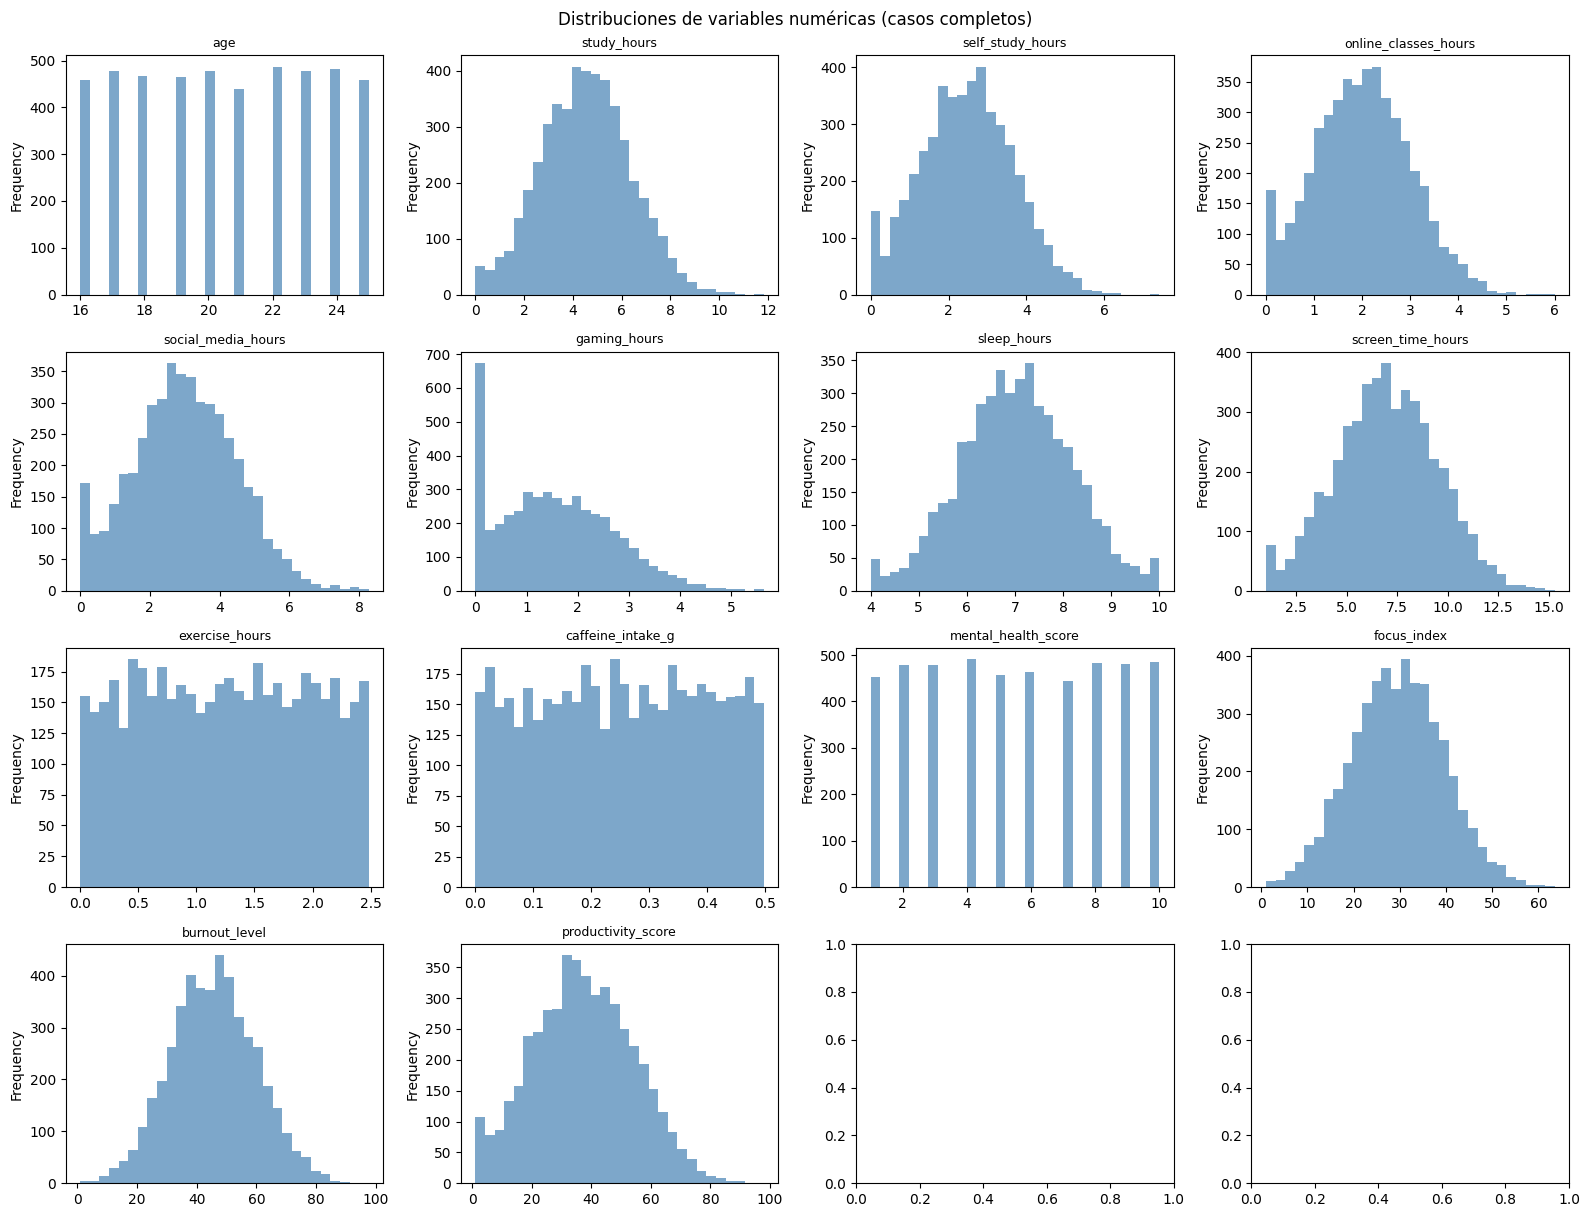

In [67]:
num_cols = ['age','study_hours','self_study_hours','online_classes_hours',
            'social_media_hours','gaming_hours','sleep_hours','screen_time_hours',
            'exercise_hours','caffeine_intake_g','mental_health_score',
            'focus_index','burnout_level','productivity_score']

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, col in enumerate(num_cols):
    ax = axes[i//4][i%4]
    df[col].plot.hist(bins=30, ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.suptitle('Distribuciones de variables numéricas (casos completos)', y=1.01, fontsize=12)
plt.show()

Basado en los histogramas y las estadisticas descriptivas del dataset original, no se detectan outliers que requieran eliminación adicional: los rangos de todas las variables numéricas son válidas para el contexto estudiado (horas de estudio, sueño, puntajes, etc.).

- Análisis de correlación

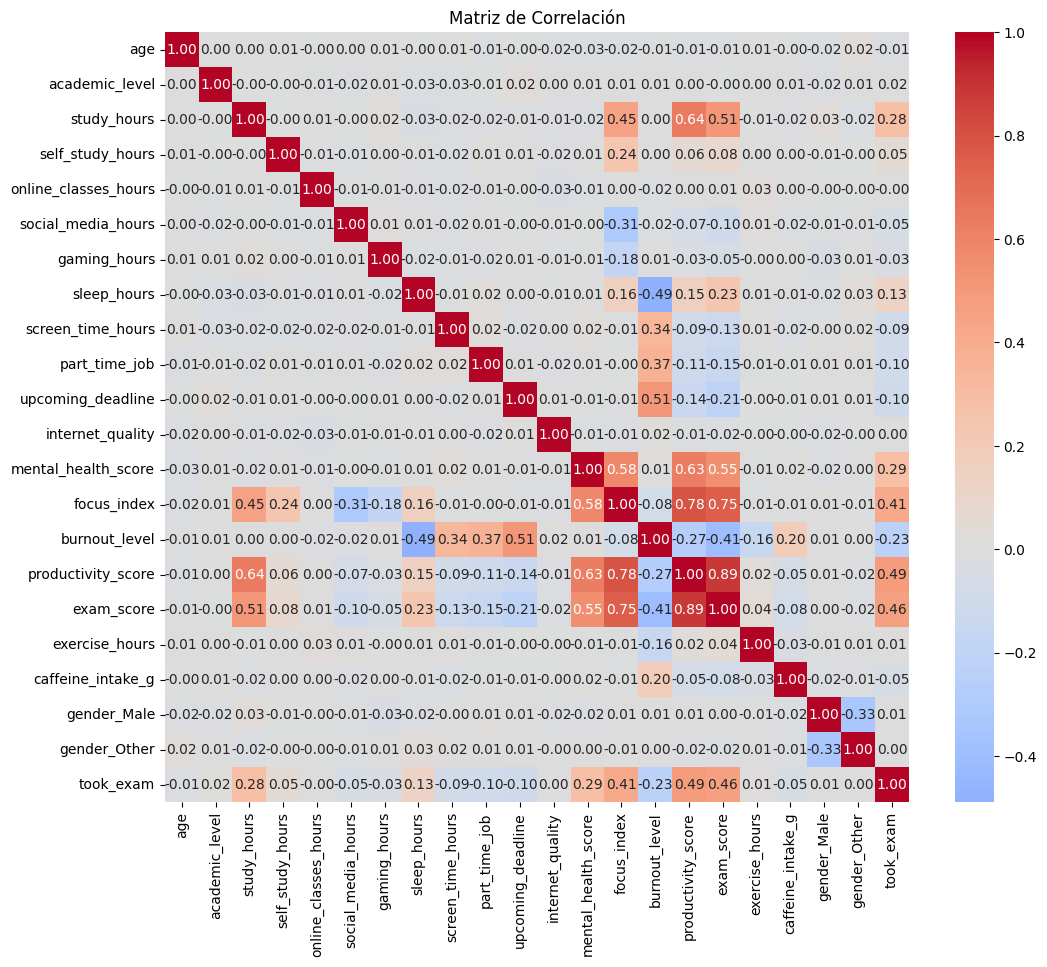

In [68]:
df_corr = corr_plot(df)

In [69]:
max_corr = max_correlacion(df.corr(), n=15)
print("Pares de variables con mayor correlación:")
display(max_corr)

Pares de variables con mayor correlación:


,Variable_1,Variable_2,Correlacion
385,productivity_score,exam_score,0.886618
338,focus_index,productivity_score,0.784966
339,focus_index,exam_score,0.750577
85,study_hours,productivity_score,0.636334
315,mental_health_score,productivity_score,0.632078
313,mental_health_score,focus_index,0.577781
316,mental_health_score,exam_score,0.547794
86,study_hours,exam_score,0.509619
268,upcoming_deadline,burnout_level,0.509402
390,productivity_score,took_exam,0.485509


- Eliminación de variables altamente correlacionadas o sin correlación

In [70]:
# Notamos, que en el bloque psicológico, hay correlaciones positivas mayores a 0.5 entre sus variables.
# Esto sugiere peligro de multicolinealidad, lo que podría afectar la estimación de los coeficientes.
# Para mitigar esto, eliminaremos la variable "focus_index" y "mental_health_score", pues tiene correlación de 0.78 con productivity_score.
df = df.drop(columns=['focus_index', 'mental_health_score']) 

# Por contexto, study_hours se divide, en parte, en online_classes_hours y self_study_hours, eliminamos estas ultimas 2
# Ya que contextualmente dicha información está contenida en study_hours, y además poseen correlación cercana a 0 con las variables objetivo

df = df.drop(columns = ["online_classes_hours", "self_study_hours"])

<Axes: >

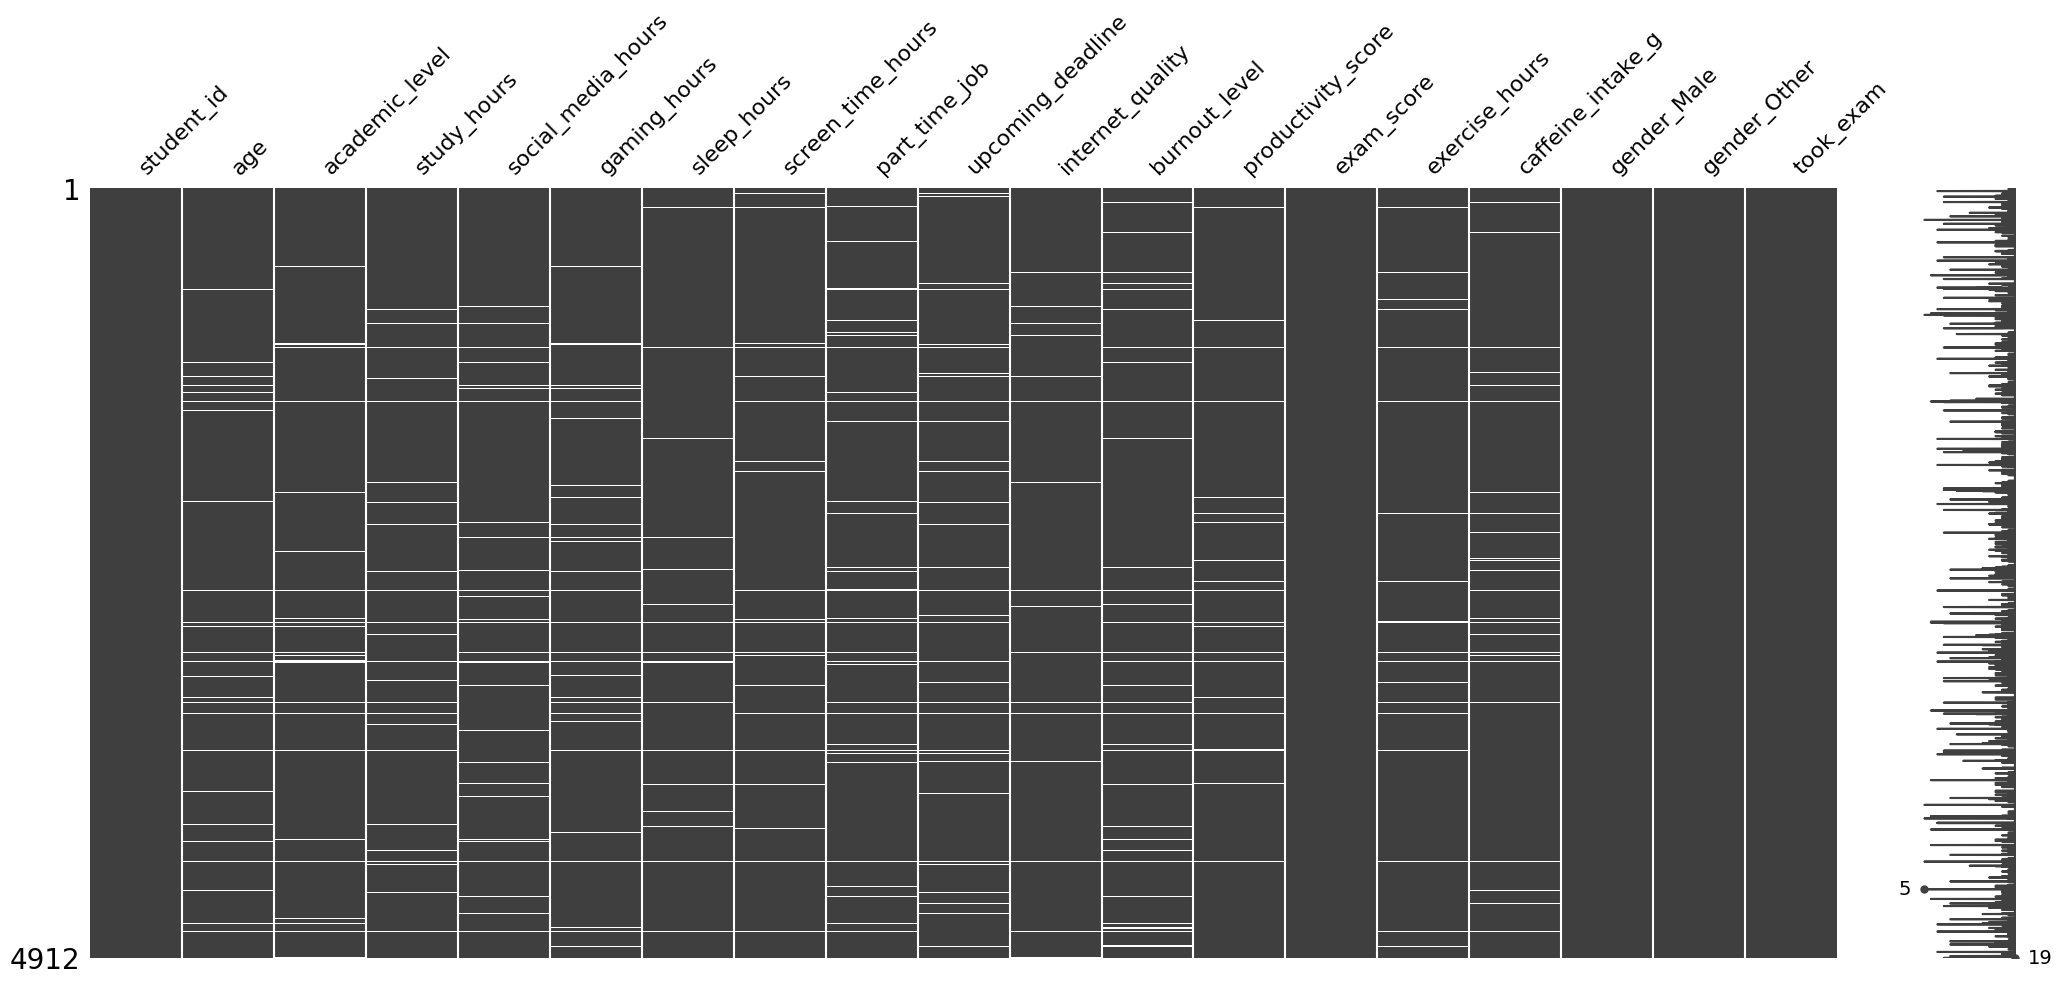

In [71]:
msno.matrix(df)

In [72]:
# Eliminación de datos faltantes en filas
#Hacemos este dropna para quedarnos con nuestro dataset final y 

df.dropna(inplace=True) # Eliminamos filas con NaN en las variables independientes, para tener un dataset limpio para el análisis
print(df.shape)

(4051, 19)


- Ejecución de Análisis de Factor de inflación de varianza

In [73]:
# Ejecutamos un test VIF para confirmar que no hay multicolinealidad entre las variables independientes restantes

vif_data = pd.DataFrame()
X = df.drop(columns=['student_id', 'exam_score', 'took_exam']).dropna()
X = sm.add_constant(X)
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

# Dado que VIF de burnout_level es mayor a 5, lo que sugiere fuerte multicolinealidad con otras variables, la eliminamos del análisis.
df = df.drop(columns=['burnout_level']) #burnout_level está explicada por otras variables.

print("Variables independientes finales: \n", df.drop(columns=['student_id', 'exam_score', 'took_exam']).columns.tolist())

              Variable         VIF
0                const  228.346481
11       burnout_level    5.582977
9    upcoming_deadline    2.458700
6          sleep_hours    2.333292
12  productivity_score    1.947637
3          study_hours    1.797010
8        part_time_job    1.750174
7    screen_time_hours    1.661632
14   caffeine_intake_g    1.222223
15         gender_Male    1.134945
16        gender_Other    1.129448
13      exercise_hours    1.118580
4   social_media_hours    1.010635
5         gaming_hours    1.006969
2       academic_level    1.004144
10    internet_quality    1.003151
1                  age    1.002641
Variables independientes finales: 
 ['age', 'academic_level', 'study_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'productivity_score', 'exercise_hours', 'caffeine_intake_g', 'gender_Male', 'gender_Other']


- Dataset final y tamaño

In [74]:
# Finalmente, mostramos el dataset limpio y listo para el análisis

print("Tamaño del dataset analítico inicial: ", f" \nfilas: {og_shape[0]}, columnas: {og_shape[1]}")
print("Columnas en dataset final: \n", df.columns.to_list())
print("Tamaño del dataset analítico final: ", f"\nfilas: {df.shape[0]}, columnas: {df.shape[1]}")
print("Perdida de información (filas): \n", round((og_shape[0] - df.shape[0])/og_shape[0] * 100, 2), "%" )

if print_output: display(df)

Tamaño del dataset analítico inicial:   
filas: 5621, columnas: 22
Columnas en dataset final: 
 ['student_id', 'age', 'academic_level', 'study_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'internet_quality', 'productivity_score', 'exam_score', 'exercise_hours', 'caffeine_intake_g', 'gender_Male', 'gender_Other', 'took_exam']
Tamaño del dataset analítico final:  
filas: 4051, columnas: 18
Perdida de información (filas): 
 27.93 %


# Códigos Pregunta 2

**Enunciado:** Ejecute un modelo de probabilidad lineal (MCO) que permita explicar la probabilidad de que un alumno rinda el examen, a partir de las informacion disponible. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.

- Modelo con todas las variables disponibles

In [75]:
# Matriz de diseño
X = df.drop(columns=["student_id","exam_score", "took_exam"]) # Covariables
X=sm.add_constant(X) #Constante

# Variable dependiente
y = df["took_exam"] # Variable dependiente

model = sm.OLS(y,X).fit(cov_type='HC1')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              took_exam   R-squared:                       0.238
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     38.40
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          2.78e-105
Time:                        20:25:36   Log-Likelihood:                -59.962
No. Observations:                4051   AIC:                             151.9
Df Residuals:                    4035   BIC:                             252.8
Df Model:                          15                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  0.6256      0

- Selección de variables

In [76]:
# Selección de variables significativas
ols_params = model.params
ols_p_values = model.pvalues

# Crear un DataFrame con los resultados
ols_results_df = pd.DataFrame({
    'coef': ols_params,
    'p-value': ols_p_values})

display(ols_results_df[ols_results_df["p-value"]<=0.05].round(4))

,coef,p-value
const,0.6256,0.0000
gaming_hours,-0.0089,0.0129
sleep_hours,0.0168,0.0000
screen_time_hours,-0.0058,0.0003
part_time_job,-0.0218,0.0046
upcoming_deadline,-0.0216,0.0050
productivity_score,0.0075,0.0000


- Modelo final OLS

In [77]:
# Matriz de diseño modelo final
X_ols = df[["gaming_hours", "sleep_hours", "screen_time_hours", "part_time_job", "upcoming_deadline", "productivity_score"]]
X_ols=sm.add_constant(X_ols) #Constante

print("Variables a utilizar: \n")
print(X_ols.columns.to_list())

# Variable dependiente
y = df["took_exam"] # Variable dependiente

model_final = sm.OLS(y,X_ols).fit(cov_type='HC1')
print(model_final.summary())

Variables a utilizar: 

['const', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'productivity_score']
                            OLS Regression Results                            
Dep. Variable:              took_exam   R-squared:                       0.237
Model:                            OLS   Adj. R-squared:                  0.236
Method:                 Least Squares   F-statistic:                     95.72
Date:                Tue, 21 Apr 2026   Prob (F-statistic):          7.82e-113
Time:                        20:25:36   Log-Likelihood:                -63.292
No. Observations:                4051   AIC:                             140.6
Df Residuals:                    4044   BIC:                             184.7
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                         coef    std err          z      P>|z|  

# Códigos Pregunta 3

**Enunciado:** Ejecute un modelo probit para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.

- Modelo con todas las variables disponibles

In [78]:
probit_model = sm.Probit(y,X).fit(cov_type='HC1')
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.126741
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4051
Model:                         Probit   Df Residuals:                     4035
Method:                           MLE   Df Model:                           15
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5699
Time:                        20:25:36   Log-Likelihood:                -513.43
converged:                       True   LL-Null:                       -1193.9
Covariance Type:                  HC1   LLR p-value:                4.342e-281
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.4389      0.504     -2.858      0.004      -2.426      -0.452
age  

- Selección de variables

In [79]:
# Selección de variables significativas

probit_params = probit_model.params
probit_p_values = probit_model.pvalues

# Crear un DataFrame con los resultados
probit_results_df = pd.DataFrame({
    'coef': probit_params,
    'p-value': probit_p_values})

display(probit_results_df[probit_results_df["p-value"]<=0.05].round(4))

,coef,p-value
const,-1.4389,0.0043
study_hours,-0.1009,0.0024
sleep_hours,0.2135,0.0000
screen_time_hours,-0.0886,0.0000
part_time_job,-0.3081,0.0008
upcoming_deadline,-0.2535,0.0042
productivity_score,0.1299,0.0000
caffeine_intake_g,-0.6031,0.0480


- Modelo final Probit

In [80]:
X_probit = df[['study_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'productivity_score', 'caffeine_intake_g']]
X_probit = sm.add_constant(X_probit)
print("Variables a utilizar en el modelo final: \n")
print(X_probit.columns.to_list())

probit_model_final = sm.Probit(y,X_probit).fit(cov_type='HC1')
print(probit_model_final.summary())

Variables a utilizar en el modelo final: 

['const', 'study_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'productivity_score', 'caffeine_intake_g']
Optimization terminated successfully.
         Current function value: 0.127722
         Iterations 9
                          Probit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4051
Model:                         Probit   Df Residuals:                     4043
Method:                           MLE   Df Model:                            7
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5666
Time:                        20:25:36   Log-Likelihood:                -517.40
converged:                       True   LL-Null:                       -1193.9
Covariance Type:                  HC1   LLR p-value:                5.962e-288
                         coef    std err          z      P>|z|      [0.025      0

- Efectos marginales Probit

In [81]:
# Cambios marginales:
marginal_effects_probit = probit_model_final.get_margeff()
print(marginal_effects_probit.summary())

       Probit Marginal Effects       
Dep. Variable:              took_exam
Method:                          dydx
At:                           overall
                        dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
study_hours           -0.0076      0.002     -3.260      0.001      -0.012      -0.003
sleep_hours            0.0149      0.003      5.136      0.000       0.009       0.021
screen_time_hours     -0.0062      0.001     -4.951      0.000      -0.009      -0.004
part_time_job         -0.0210      0.006     -3.293      0.001      -0.033      -0.008
upcoming_deadline     -0.0173      0.006     -2.756      0.006      -0.030      -0.005
productivity_score     0.0092      0.000     28.234      0.000       0.009       0.010
caffeine_intake_g     -0.0427      0.022     -1.972      0.049      -0.085      -0.000


# Códigos Pregunta 4


**Enunciado:** Ejecute un modelo logit para responder a la pregunta 2. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.



- Modelo con todas las variables disponibles

In [82]:
logit_model = sm.Logit(y,X).fit(cov_type='HC1')
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.127035
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4051
Model:                          Logit   Df Residuals:                     4035
Method:                           MLE   Df Model:                           15
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5689
Time:                        20:25:36   Log-Likelihood:                -514.62
converged:                       True   LL-Null:                       -1193.9
Covariance Type:                  HC1   LLR p-value:                1.413e-280
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -2.9348      0.934     -3.141      0.002      -4.766      -1.104
age 

- Selección de variables

In [83]:
# Selección de variables significativas

logit_params = logit_model.params
logit_conf_int = logit_model.conf_int()  # intervalo de confianza al 95% por defecto
logit_p_values = logit_model.pvalues

# Crear un DataFrame con los resultados
logit_results_df = pd.DataFrame({
    'coef': logit_params,
    'p-value': logit_p_values})

display(logit_results_df[logit_results_df["p-value"]<=0.05].round(4))

,coef,p-value
const,-2.9348,0.0017
study_hours,-0.1885,0.0028
sleep_hours,0.4076,0.0000
screen_time_hours,-0.1566,0.0000
part_time_job,-0.5662,0.0010
upcoming_deadline,-0.3958,0.0171
productivity_score,0.2387,0.0000


- Modelo final Logit

In [84]:
X_logit = df[['study_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'productivity_score']]
X_logit = sm.add_constant(X_logit)
print("Variables a utilizar en el modelo final: \n")
print(X_logit.columns.to_list())

logit_model_final = sm.Logit(y,X_logit).fit(cov_type='HC1')
print(logit_model_final.summary())

Variables a utilizar en el modelo final: 

['const', 'study_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'productivity_score']
Optimization terminated successfully.
         Current function value: 0.128368
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:              took_exam   No. Observations:                 4051
Model:                          Logit   Df Residuals:                     4044
Method:                           MLE   Df Model:                            6
Date:                Tue, 21 Apr 2026   Pseudo R-squ.:                  0.5644
Time:                        20:25:36   Log-Likelihood:                -520.02
converged:                       True   LL-Null:                       -1193.9
Covariance Type:                  HC1   LLR p-value:                5.159e-288
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------

- Efectos marginales Logit

In [85]:
# Cambios marginales:
marginal_effects_logit = logit_model_final.get_margeff()
print(marginal_effects_logit.summary())

        Logit Marginal Effects       
Dep. Variable:              took_exam
Method:                          dydx
At:                           overall
                        dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
study_hours           -0.0079      0.002     -3.282      0.001      -0.013      -0.003
sleep_hours            0.0157      0.003      5.466      0.000       0.010       0.021
screen_time_hours     -0.0060      0.001     -4.796      0.000      -0.008      -0.004
part_time_job         -0.0208      0.006     -3.211      0.001      -0.033      -0.008
upcoming_deadline     -0.0141      0.006     -2.213      0.027      -0.027      -0.002
productivity_score     0.0092      0.000     27.905      0.000       0.009       0.010


# Códigos Problema 5

**Enunciado:** Comente los resultados obtenidos en 2, 3 y 4. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investigación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [86]:
# Stargazer para ver comparativa directa de modelos (como en R)
stargazer = Stargazer([model_final, probit_model_final, logit_model_final])
stargazer.title("Comparación de Modelos finales: OLS, Probit y Logit")
stargazer.custom_columns(["Modelo OLS", "Modelo Probit", "Modelo Logit"], [1, 1, 1])

HTML(stargazer.render_html())

# Códigos Problema 6

**Enunciado:** Use un modelo Poisson para explicar la nota del examen, entre aquellos alumnos que lo rindieron. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.


- Modelo con todas las variables disponibles

In [87]:
# Nos centramos solo en aquellos alumnos que si asistieron al examen, para explicar su nota del examen con un modelo Poisson.
df_exam = df[df['took_exam'] == 1]
# Poisson y BN exigen números enteros (conteo). Redondeamos la nota.
df_exam['exam_score_int'] = df_exam['exam_score'].round().astype(int)
X = df_exam.drop(columns=['student_id', 'exam_score', 'took_exam', 'exam_score_int']) # Eliminamos la columna original de nota del examen
X = sm.add_constant(X) # Agregamos la constante al modelo
yy = df_exam['exam_score_int']

poisson_model = sm.GLM(yy, X, family=sm.families.Poisson()).fit()
print(poisson_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         exam_score_int   No. Observations:                 3700
Model:                            GLM   Df Residuals:                     3684
Model Family:                 Poisson   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12104.
Date:                Tue, 21 Apr 2026   Deviance:                       6948.7
Time:                        20:25:36   Pearson chi2:                 6.43e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9910
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.7404      0

- Selección de variables

In [88]:
poisson_params = poisson_model.params
poisson_conf_int = poisson_model.conf_int()  # intervalo de confianza al 95% por defecto
poisson_p_values = poisson_model.pvalues

# Crear un DataFrame con los resultados
poisson_results_df = pd.DataFrame({
    'coef': poisson_params,
    'p-value': poisson_p_values})

display(poisson_results_df[poisson_results_df["p-value"]<=0.05].round(4))

,coef,p-value
const,1.7404,0.0000
study_hours,-0.0166,0.0000
social_media_hours,-0.0196,0.0000
gaming_hours,-0.0137,0.0000
sleep_hours,0.0485,0.0000
screen_time_hours,-0.0129,0.0000
part_time_job,-0.0570,0.0000
upcoming_deadline,-0.1163,0.0000
productivity_score,0.0296,0.0000
exercise_hours,0.0160,0.0016


- Modelo final Poisson

In [89]:
X_poisson = df_exam[["study_hours", "social_media_hours", "gaming_hours", "sleep_hours", "screen_time_hours", "part_time_job", "upcoming_deadline", "productivity_score", "exercise_hours", "caffeine_intake_g"]]
X_poisson = sm.add_constant(X_poisson) # Agregamos la constante al modelo

print("Variables a utilizar: \n")
print(X_poisson.columns.to_list())

poisson_model_final = sm.GLM(yy, X_poisson, family=sm.families.Poisson()).fit()
print(poisson_model_final.summary())

Variables a utilizar: 

['const', 'study_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'productivity_score', 'exercise_hours', 'caffeine_intake_g']
                 Generalized Linear Model Regression Results                  
Dep. Variable:         exam_score_int   No. Observations:                 3700
Model:                            GLM   Df Residuals:                     3689
Model Family:                 Poisson   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -12105.
Date:                Tue, 21 Apr 2026   Deviance:                       6952.3
Time:                        20:25:36   Pearson chi2:                 6.44e+03
No. Iterations:                     4   Pseudo R-squ. (CS):             0.9910
Covariance Type:            nonrobust                              

- Dataframe para interpretación de coeficientes

In [90]:
poisson_params_f = poisson_model_final.params
poisson_conf_int_f = poisson_model_final.conf_int()  # intervalo de confianza al 95% por defecto
poisson_p_values_f = poisson_model_final.pvalues

# Calcular exp(beta) y exp(IC)
exp_params = np.exp(poisson_params_f)
pct_change = 100*(exp_params-1) 

# Crear un DataFrame con los resultados
poisson_f_results_df = pd.DataFrame({
    'coef': poisson_params_f,
    'exp(coef)': exp_params,
    'pct_change': pct_change,
    'p-value': poisson_p_values_f})

display(poisson_f_results_df[poisson_f_results_df["p-value"]<=0.05].round(4))

,coef,exp(coef),pct_change,p-value
const,1.7214,5.5924,459.2393,0.0000
study_hours,-0.0167,0.9834,-1.6560,0.0000
social_media_hours,-0.0195,0.9807,-1.9326,0.0000
gaming_hours,-0.0135,0.9866,-1.3380,0.0000
sleep_hours,0.0488,1.0501,5.0062,0.0000
screen_time_hours,-0.0129,0.9872,-1.2809,0.0000
part_time_job,-0.0573,0.9443,-5.5697,0.0000
upcoming_deadline,-0.1169,0.8896,-11.0367,0.0000
productivity_score,0.0296,1.0301,3.0064,0.0000
exercise_hours,0.0161,1.0162,1.6210,0.0015


# Códigos Pregunta 7

**Enunciado:** Determine si existe sobre dispersion en la data y posible valor optimo de alpha para un modelo Binomial Negativa.

count    3700.000000
mean       20.533784
std        11.286349
min         1.000000
25%        12.000000
50%        19.000000
75%        28.000000
max        64.000000
Name: exam_score_int, dtype: float64

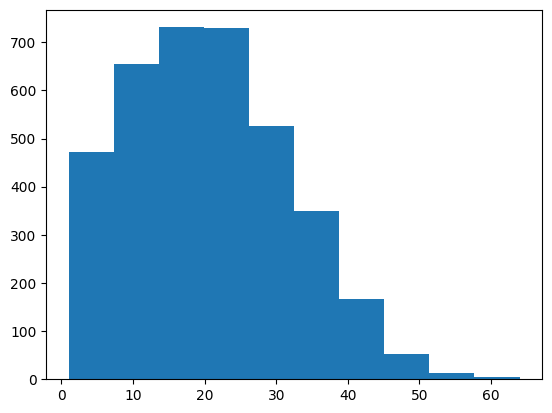

In [91]:
# Analisis de distribución de variable objetivo exam_score_int
plt.hist(yy)
yy.describe()

- Test de sobredispersión

In [92]:
# Prueba rápida de sobredispersión usando ratio $chi^2/gl(res)$
pearson_chi2 = poisson_model_final.pearson_chi2
df_resid = poisson_model_final.df_resid

ratio = pearson_chi2 / df_resid
print(f"Pearson chi2 = {pearson_chi2:.3f}")
print(f"df_resid = {df_resid}")
print(f"Ratio = {ratio:.3f}")

if ratio >1: print("Datos con sobredispersión")
else: print("Datos no presentan sobredispersión")

Pearson chi2 = 6438.353
df_resid = 3689
Ratio = 1.745
Datos con sobredispersión


- Obtención de $\alpha$ optimo

In [93]:
# Obtenemos los predict del modelo de Poisson
df_exam["ppredictions"] = poisson_model_final.predict(X_poisson)

aux=((df_exam['exam_score_int']-df_exam['ppredictions'])**2-df_exam['ppredictions'])/df_exam['ppredictions']
auxr=sm.OLS(aux,df_exam['ppredictions']).fit()
print(auxr.summary())

alpha_opt = auxr.params.iloc[0]
p_val_alpha = auxr.pvalues.iloc[0]
print(f"Valor óptimo calculado de Alpha: {alpha_opt:.4f}")
print(f"P-valor de Alpha: {p_val_alpha:.4f}")


                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.051
Model:                            OLS   Adj. R-squared (uncentered):              0.050
Method:                 Least Squares   F-statistic:                              197.0
Date:                Tue, 21 Apr 2026   Prob (F-statistic):                    1.22e-43
Time:                        20:25:36   Log-Likelihood:                         -8502.8
No. Observations:                3700   AIC:                                  1.701e+04
Df Residuals:                    3699   BIC:                                  1.701e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------

# Códigos Pregunta 8

**Enunciado:** Usando la informacion anterior, ejecute un modelo Binomial Negativa para responder a la pregunta 6. Seleccione las variables dependientes a incluir en el modelo final e interprete su significado.



- Modelo con todas las variables disponibles

In [94]:
# Dado que tenemos sobredispersión de datos, es razonable utilizar Binomial Negativa por sobre Poisson

nb_model = sm.GLM(yy, X, family=sm.families.NegativeBinomial(alpha=alpha_opt)).fit(disp=False)
print(nb_model.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:         exam_score_int   No. Observations:                 3700
Model:                            GLM   Df Residuals:                     3684
Model Family:        NegativeBinomial   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11852.
Date:                Tue, 21 Apr 2026   Deviance:                       5014.0
Time:                        20:25:36   Pearson chi2:                 4.57e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9596
Covariance Type:            nonrobust                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  1.6829      0

- Selección de variables

In [95]:
nb_params = nb_model.params
nb_conf_int = nb_model.conf_int()  # intervalo de confianza al 95% por defecto
nb_p_values = nb_model.pvalues

# Crear un DataFrame con los resultados
nb_results_df = pd.DataFrame({
    'coef': nb_params,
    'p-value': nb_p_values})

display(nb_results_df[nb_results_df["p-value"]<=0.05].round(4))

,coef,p-value
const,1.6829,0.0000
study_hours,-0.0158,0.0000
social_media_hours,-0.0214,0.0000
gaming_hours,-0.0152,0.0002
sleep_hours,0.0527,0.0000
screen_time_hours,-0.0141,0.0000
part_time_job,-0.0614,0.0000
upcoming_deadline,-0.1259,0.0000
productivity_score,0.0309,0.0000
exercise_hours,0.0169,0.0079


- Modelo final Binomial Negativa

In [96]:
X_nb = df_exam[["study_hours", "social_media_hours", "gaming_hours", "sleep_hours", "screen_time_hours", "part_time_job", "upcoming_deadline", "productivity_score", "exercise_hours", "caffeine_intake_g"]]
X_nb = sm.add_constant(X_nb) # Agregamos la constante al modelo

print("Variables a utilizar: \n")
print(X_poisson.columns.to_list())

nb_model_final = sm.GLM(yy, X_nb, family=sm.families.NegativeBinomial(alpha=alpha_opt)).fit(disp=False)
print(nb_model_final.summary())

Variables a utilizar: 

['const', 'study_hours', 'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 'part_time_job', 'upcoming_deadline', 'productivity_score', 'exercise_hours', 'caffeine_intake_g']
                 Generalized Linear Model Regression Results                  
Dep. Variable:         exam_score_int   No. Observations:                 3700
Model:                            GLM   Df Residuals:                     3689
Model Family:        NegativeBinomial   Df Model:                           10
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -11853.
Date:                Tue, 21 Apr 2026   Deviance:                       5015.9
Time:                        20:25:36   Pearson chi2:                 4.57e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9596
Covariance Type:            nonrobust                              

- Dataframe para interpretación de coeficientes

In [97]:
nb_f_params = nb_model_final.params
nb_f_p_values = nb_model_final.pvalues

# Calcular exp(beta)
nb_exp_params = np.exp(nb_f_params)
nb_pct_change = 100*(nb_exp_params-1) 

# Crear un DataFrame con los resultados
nb_f_results_df = pd.DataFrame({
    'coef': nb_f_params,
    'exp(coef)': nb_exp_params,
    'pct_change': nb_pct_change,
    'p-value': nb_f_p_values})

display(nb_f_results_df[nb_f_results_df["p-value"]<=0.05].round(4))

,coef,exp(coef),pct_change,p-value
const,1.6565,5.2408,424.0790,0.0000
study_hours,-0.0159,0.9842,-1.5814,0.0000
social_media_hours,-0.0213,0.9790,-2.1035,0.0000
gaming_hours,-0.0150,0.9851,-1.4893,0.0003
sleep_hours,0.0530,1.0544,5.4390,0.0000
screen_time_hours,-0.0141,0.9860,-1.3958,0.0000
part_time_job,-0.0615,0.9403,-5.9652,0.0000
upcoming_deadline,-0.1264,0.8813,-11.8706,0.0000
productivity_score,0.0309,1.0314,3.1383,0.0000
exercise_hours,0.0169,1.0171,1.7079,0.0076


# Códigos Pregunta 9

**Enunciado:** Comente los resultados obtenidos en 6, 7 y 8. ¿Cuáles y por qué existen las diferencias entre los resultados?. En su opinión, ¿Cuál sería el más adecuado para responder la pregunta de investgación y por qué? ¿Qué variables resultaron ser robustas a la especificación?

In [99]:
# Log‑likelihood
poisson_llf = poisson_model_final.llf
nb_llf = nb_model_final.llf

# Pseudo‑R² de Cox‑Snell
poisson_psr_cs = poisson_model_final.pseudo_rsquared(kind='cs')
nb_psr_cs = nb_model_final.pseudo_rsquared(kind='cs')

stargazer = Stargazer([poisson_model_final, nb_model_final])
stargazer.title("Comparación de Modelos: Poisson y Binomial Negativa")
stargazer.custom_columns(["Modelo Poisson", "Modelo Binomial Negativa"], [1, 1])
stargazer.add_line('Log-Likelihood', 
                   [f'{poisson_llf:.2f}', f'{nb_llf:.2f}'])
stargazer.add_line('Pseudo R² (Cox-Snell)', 
                   [f'{poisson_psr_cs:.3f}', f'{nb_psr_cs:.3f}'])

HTML(stargazer.render_html())